# Lecture 7: PyTorch

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import tqdm
from sklearn.inspection import DecisionBoundaryDisplay

def plot_boundary(model, X, y, alpha=1, title=''):
    xrange = (-X[:, 0].min() + X[:, 0].max()) / 10
    yrange = (-X[:, y].min() + X[:, y].max()) / 10
    feature_1, feature_2 = np.meshgrid(
        np.linspace(X[:, 0].min() - xrange, X[:, 0].max() + xrange, 250),
        np.linspace(X[:, 1].min() - yrange, X[:, 1].max() + yrange, 250)
    )
    grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
    y_pred = np.reshape(model.predict(torch.tensor(grid).float()).detach().numpy(), feature_1.shape)
    display = DecisionBoundaryDisplay(
        xx0=feature_1, xx1=feature_2, response=y_pred
    )
    display.plot()
    display.ax_.scatter(
        X[:, 0], X[:, 1], c=y, alpha=alpha, edgecolor="black"
    )
    plt.title(title)
    plt.show()

## Introduction to PyTorch

The most basic object in PyTorch is a `tensor`. Tensor objects behave much like the `AutogradValue` objects we are creating in the homework! We can create a `tensor` object with a given value as follows

In [4]:
x = torch.tensor(4.)
x

tensor(4.)

Performing basic operations on `tensor` objects gives tensor objects.

In [5]:
a = x ** 2 + 5
a

tensor(21.)

`tensor` objects also support reverse-mode automatic differentiation! To use this, we must specify that we will want to compute the derivative with respect to a given `tensor`. We can do this with the `requires_grad` argument.

In [8]:
x = torch.tensor(4., requires_grad=True)

Once we have a `tensor` that `requires_grad`, we can perform operations on it to compute a loss.

In [9]:
a = x ** 2 + 5
L = torch.log(a) # Functions like log must be called through torch
L

tensor(3.0445, grad_fn=<LogBackward0>)

Once we have a loss running the backward pass is done exactly as in the homework. First we call `backward()` on the loss `tensor` object, then we can access the derivative through the `grad` property of `x`.

In [10]:
L.backward()
x.grad

tensor(0.3810)

We can also create `tensor` objects that wrap arrays.

In [11]:
x = torch.tensor(np.array([3, 4, 5]))
x

tensor([3, 4, 5])

We can also just directly create tensors as we would numpy arrays

In [12]:
x = torch.tensor([3, 4, 5])
x

tensor([3, 4, 5])

Including convienience constructors.

In [13]:
print(torch.ones((5,)))
print(torch.zeros((2, 3)))

tensor([1., 1., 1., 1., 1.])
tensor([[0., 0., 0.],
        [0., 0., 0.]])


Automatic differentiation still works for arrays. In this case it gives use the gradient of the loss (hence the `grad` property).

In [15]:
x = torch.tensor([3., 4., 5.], requires_grad=True)
L = torch.sum(x ** 2)
L

tensor(50., grad_fn=<SumBackward0>)

In [16]:
L.grad

/var/folders/ct/cvh0qs6j5rlbcp004rxwtwh80000gn/T/ipykernel_75974/323164392.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  L.grad


In [17]:
L.backward()
x.grad

tensor([ 6.,  8., 10.])

We can convert `tensor` objects back to numpy by calling `x.detach().numpy()`. (`detach` removes the variable from any automatic differentiation computations)

In [18]:
x.detach().numpy()

array([3., 4., 5.], dtype=float32)

At this point it's probably worth remarking on where the name `tensor` comes from. 

So far we've discussed 3 kinds of array objects
- **Scalars:** which are just single values (0-dimensional)
- **Vectors:** 1-dimensional arrays of numbers
- **Matrices:** 2-dimensional arrays of numbers

![Alt text](image.png)

A **tensor** is the generalization of a vector or matrix to *any* number of dimensions. For example, a 3-dimensional tensor can be seen in multiple ways.

![Alt text](image-1.png)

A `tensor` object can be created with any number of dimensions. For example, we could create a 2x2x2 tensor as:

In [57]:
t = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
t

tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])

Or we could create the tensor in the image using `arange` and `reshape`.

In [58]:
t = torch.arange(30).reshape((3, 2, 5))
t

tensor([[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]],

        [[10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]],

        [[20, 21, 22, 23, 24],
         [25, 26, 27, 28, 29]]])

4-dimensional tensors can also be visualized

![Alt text](image-2.png)

In [59]:
t = torch.ones((3, 2, 4, 5))
t.shape

torch.Size([3, 2, 4, 5])

There are some notable differences between torch and numpy when it comes to operations. The important one to watch out for at this point is matrix multiplation. In numpy we accomplished with with `np.dot`:

In [60]:
x = np.ones((4, 5))
w = np.ones((5, 2))
np.dot(x, w)

array([[5., 5.],
       [5., 5.],
       [5., 5.],
       [5., 5.]])

In PyTorch `torch.dot` only does vector dot products and thus only applies to 1-dimensional `tensor` objects:

In [61]:
x = torch.ones((4, 5))
w = torch.ones((5, 2))
torch.dot(x, w)

RuntimeError: 1D tensors expected, but got 2D and 2D tensors

Instead we use the `torch.matmul` function for this purpose

In [62]:
torch.matmul(x, w)

tensor([[5., 5.],
        [5., 5.],
        [5., 5.],
        [5., 5.]])

PyTorch also has many handy built-in functions that numpy doesn't have, such as `sigmoid`.

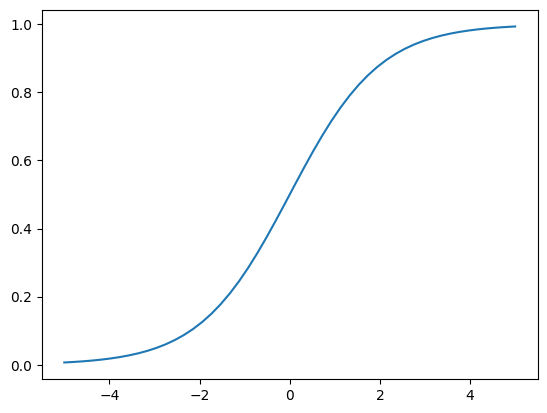

In [63]:
x = torch.linspace(-5, 5, 50)
s = torch.sigmoid(x)
plt.plot(x, s)

This makes it very easy to implement something like logistic regression. 

In [19]:
class LogisticRegression:
    def __init__(self, dims):
        self.weights = torch.ones((dims,), requires_grad=True)
        self.bias = torch.zeros((), requires_grad=True)

    def predict_probability(self, X):
        f_X = torch.matmul(X, self.weights) + self.bias
        return torch.sigmoid(f_X)

    def predict(self, X):
        return self.predict_probability(X) > 0.5


Let's try loading a dataset, converting it to `tensor` and making predictions

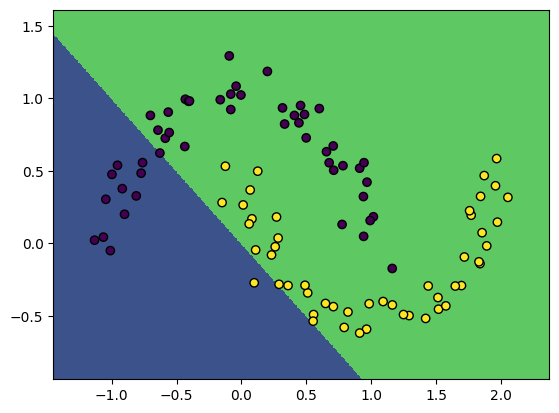

In [20]:
X, y = make_moons(noise=0.1)
X, y = torch.tensor(X).float(), torch.tensor(y)

model = LogisticRegression(2)
plot_boundary(model, X, y)

When working with PyTorch, it is convention to separate the loss function from the model, where the loss function will just take predictions and labels.

In [21]:
def NLL(pred, y):
    LL = y * torch.log(pred) + (1. - y) * torch.log(1. - pred)
    return -LL.sum()

## Gradient descent

Gradient descent is also implemented in PyTorch in the `optim` module.

In [22]:
from torch import optim

Gradient descent works a bit differently in PyTorch than what we've seen. We first need to construct a gradient descent *object* which specifies which values we're optimizing and what the learning rate will be. We specify the values to optimize by simply passing a list of weights/parameters to the constructor.

In PyTorch, basic gradient descent is encapsulated in the `optim.SGD` class (`SGD` stands for *stochastic gradient descent*, we'll talk about what *stochastic* means in this context next week.)

In [24]:
optimizer = optim.SGD([model.weights, model.bias], lr=0.1)

Notice that this object doesn't even take in the function we're trying to optimize, only the inputs. We need to call the function ourselves *and* run `backward()` to compute the gradients. 

In [25]:
predictions = model.predict_probability(X)
loss = NLL(predictions, y)
loss.backward()


Let's look at our model `weights`

In [26]:
model.weights
model.weights.grad

tensor([-5.7585, 23.9640])

We can take a single step of gradient descent using the `step` method of the optimizer.

In [27]:
optimizer.step()
model.weights

tensor([ 1.5758, -1.3964], requires_grad=True)

We see that this actually updates the weights themselves!

It's important to note that in PyTorch, calling `backward` does **not** clear the value stored in grad. So computing the gradient multiple times will result in updates to the gradient.

In [72]:
print(model.weights.grad)
NLL(model.predict_probability(X), y).backward()
print(model.weights.grad)
NLL(model.predict_probability(X), y).backward()
print(model.weights.grad)

tensor([-5.6526, 24.1355])
tensor([-14.5242,  28.7704])
tensor([-23.3958,  33.4053])


We can clear the stored gradients using the optimizer.

In [28]:
optimizer.zero_grad()
print(model.weights.grad)

None


So far we've only taking a single step of gradient descent. In order to run many steps, we need to write a loop to do everything we just saw.

In [30]:
for i in range(10):
    predictions = model.predict_probability(X)
    loss = NLL(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

29.2781925201416
29.171977996826172
29.088302612304688
29.021621704101562
28.968017578125
28.924606323242188
28.889232635498047
28.86025619506836
28.836408615112305
28.816699981689453


We should now see that our model has been optimized!

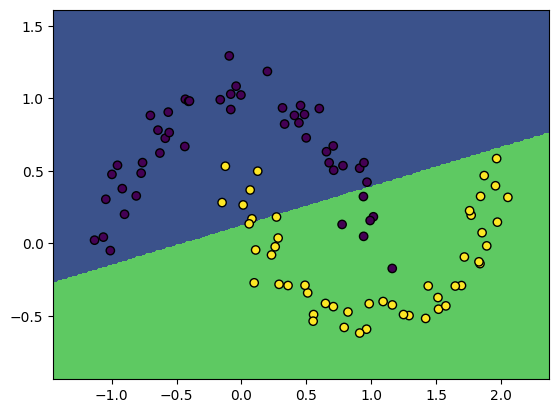

In [31]:
plot_boundary(model, X, y)

## torch.nn

While PyTorch as a tool for automatic differentiation and optimization would be useful by itself. It actually gives us a lot more than that!

On of the most important features of PyTorch is its model-building tools in the `torch.nn` module. This gives us a lot of powerful features that we can use to build complex neural networks!



In [32]:
from torch import nn

Let's start by building out logistic regression model in the `torch.nn` framwork. In order for a model to benefit from `torch.nn` our model class needs to inheret from `nn.Module`

In [35]:
class LogisticRegression(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.weights = nn.Parameter(torch.ones((dims,)))
        self.bias = nn.Parameter(torch.zeros(()))

    def forward(self, X):
        return torch.sigmoid(torch.matmul(X, self.weights) + self.bias)

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

There are 2 changes to note here. The first is that we wrapped our `weights` and `bias` terms in `nn.Parameter`. This tells PyTorch that these are the parameters we will want to optimize. We don't need to specify `requires_grad` for parameters, PyTorch will take care of that for us.

The second is that we moved the implmentation of `predict_probability` to `forward`. In PyTorch models the `forward` method is special, it defines the model as a function. If we call the model as a function `forward` will be called internally.

In [36]:
model = LogisticRegression(2)
model(X)

tensor([0.6073, 0.9278, 0.5424, 0.5173, 0.7439, 0.8772, 0.8974, 0.5502, 0.6987,
        0.8355, 0.7816, 0.4283, 0.9121, 0.8455, 0.6889, 0.7990, 0.3680, 0.5591,
        0.8792, 0.7797, 0.7291, 0.6511, 0.7684, 0.5844, 0.5021, 0.5345, 0.6369,
        0.7590, 0.7838, 0.5924, 0.8000, 0.7205, 0.5517, 0.4489, 0.6392, 0.3228,
        0.5331, 0.7293, 0.8069, 0.7124, 0.5531, 0.6769, 0.7687, 0.6113, 0.3318,
        0.8929, 0.8031, 0.3815, 0.7743, 0.7395, 0.7606, 0.5730, 0.2479, 0.9147,
        0.8220, 0.5794, 0.5679, 0.6414, 0.7349, 0.8178, 0.5692, 0.5451, 0.9134,
        0.3724, 0.5344, 0.8006, 0.7596, 0.5164, 0.4987, 0.7983, 0.8732, 0.5583,
        0.7587, 0.5381, 0.5162, 0.6387, 0.7775, 0.3973, 0.5043, 0.7714, 0.6664,
        0.7843, 0.6959, 0.8670, 0.8033, 0.8461, 0.5624, 0.7949, 0.7116, 0.7890,
        0.6007, 0.2573, 0.5577, 0.5863, 0.7733, 0.6812, 0.4568, 0.7581, 0.5486,
        0.2648], grad_fn=<SigmoidBackward0>)

This means that we can use instances of `nn.Module` as parameterized functions. For example, we might create a general linear (technically affine) function in the same way.

$$f(\mathbf{x}) = \mathbf{x}^T\mathbf{W}^T + \mathbf{b},  \quad f: \mathbb{R}^i \rightarrow \mathbb{R}^o$$

Note that here we are **not** assuming an augmented representation of $\mathbf{x}$.

In [37]:
class Linear(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.weightsT = nn.Parameter(torch.ones((inputs, outputs)))
        self.bias = nn.Parameter(torch.zeros((outputs,)))

    def forward(self, X):
        return torch.matmul(X, self.weightsT) + self.bias

We can use this module to implement out logistic regression model above.

In [38]:
class LogisticRegression(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.linear = Linear(dims, 1)                       # Dims input 1 output

    def forward(self, X):
        return torch.sigmoid(self.linear(X)).reshape((-1,)) # Turn output into a vector

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

In [40]:
model = LogisticRegression(2)
model(X)

tensor([0.6073, 0.9278, 0.5424, 0.5173, 0.7439, 0.8772, 0.8974, 0.5502, 0.6987,
        0.8355, 0.7816, 0.4283, 0.9121, 0.8455, 0.6889, 0.7990, 0.3680, 0.5591,
        0.8792, 0.7797, 0.7291, 0.6511, 0.7684, 0.5844, 0.5021, 0.5345, 0.6369,
        0.7590, 0.7838, 0.5924, 0.8000, 0.7205, 0.5517, 0.4489, 0.6392, 0.3228,
        0.5331, 0.7293, 0.8069, 0.7124, 0.5531, 0.6769, 0.7687, 0.6113, 0.3318,
        0.8929, 0.8031, 0.3815, 0.7743, 0.7395, 0.7606, 0.5730, 0.2479, 0.9147,
        0.8220, 0.5794, 0.5679, 0.6414, 0.7349, 0.8178, 0.5692, 0.5451, 0.9134,
        0.3724, 0.5344, 0.8006, 0.7596, 0.5164, 0.4987, 0.7983, 0.8732, 0.5583,
        0.7587, 0.5381, 0.5162, 0.6387, 0.7775, 0.3973, 0.5043, 0.7714, 0.6664,
        0.7843, 0.6959, 0.8670, 0.8033, 0.8461, 0.5624, 0.7949, 0.7116, 0.7890,
        0.6007, 0.2573, 0.5577, 0.5863, 0.7733, 0.6812, 0.4568, 0.7581, 0.5486,
        0.2648], grad_fn=<ViewBackward0>)

The power here is that because `Linear` is also an instance of `nn.Module`, PyTorch knows that it's weights should also be considered part of our models weights. We can access the weights of a model using the `parameters()` method.

In [41]:
list(model.parameters())

[Parameter containing:
 tensor([[1.],
         [1.]], requires_grad=True),
 Parameter containing:
 tensor([0.], requires_grad=True)]

This lets us easily apply gradient descent:

In [44]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

for i in range(10):
    predictions = model(X)        # Now we can just call model!
    loss = NLL(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

29.415023803710938
29.2781925201416
29.171977996826172
29.088302612304688
29.021621704101562
28.968017578125
28.924606323242188
28.889232635498047
28.86025619506836
28.836408615112305


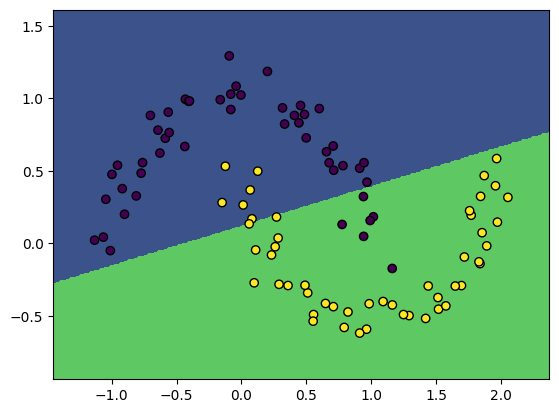

In [45]:
plot_boundary(model, X, y)

PyTorch unsurprisingly also provides a built-in `Linear` module. As `nn.Linear`.

In [48]:
nn.Linear(2, 1)

Linear(in_features=2, out_features=1, bias=True)

Knowing how to make a parameterized function in PyTorch, let's consider making a neural network layer with a sigmoid activation function.

$$f(\mathbf{x}) = \sigma(\mathbf{x}^T\mathbf{W}^T + \mathbf{b})$$

In [49]:
class SigmoidLayer(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.linear = nn.Linear(inputs, outputs)

    def forward(self, X):
        return torch.sigmoid(self.linear(X))
        

Let's create a layer with 10 neurons. (So $\mathbf{W}:\ (10 \times 2)$)

In [50]:
layer = SigmoidLayer(2, 10)
print(X.shape)
layer(X).shape

torch.Size([100, 2])


torch.Size([100, 10])

Let's use this to create a neural network class for binary classification!

In [51]:
class NeuralNetwork(nn.Module):
    def __init__(self, dims, hidden_size):
        super().__init__()
        self.layer = SigmoidLayer(dims, hidden_size)
        self.linear = Linear(hidden_size, 1)                       

    def forward(self, X):
        hidden_neurons = self.layer(X)
        output = self.linear(hidden_neurons)
        return torch.sigmoid(output).reshape((-1,))

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

We see that PyTorch recognizes both the parameters of the logistic regression and the parameters of our neural network feature transform:

In [52]:
model = NeuralNetwork(2, 10)
list(model.parameters())

[Parameter containing:
 tensor([[ 0.7038,  0.1434],
         [ 0.5929,  0.2296],
         [ 0.2330, -0.5812],
         [-0.3396, -0.1197],
         [-0.3198,  0.0417],
         [-0.5679, -0.1247],
         [ 0.5394,  0.2013],
         [ 0.6304,  0.5020],
         [-0.6214,  0.0787],
         [-0.1021, -0.2056]], requires_grad=True),
 Parameter containing:
 tensor([-0.5477, -0.6519,  0.6022, -0.3886, -0.5173,  0.3665,  0.7046,  0.0111,
         -0.3473,  0.3034], requires_grad=True),
 Parameter containing:
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.]], requires_grad=True),
 Parameter containing:
 tensor([0.], requires_grad=True)]

This means that we can easily run our optimization as before.

In [53]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

for i in range(100):
    predictions = model(X)        # Now we can just call model!
    loss = NLL(predictions, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

246.26132202148438
484.4339599609375
68.8459243774414
66.96121215820312
65.21383666992188
63.733001708984375
62.822509765625
64.00257873535156
66.73455810546875
71.82123565673828
71.44861602783203
69.7403335571289
62.79584503173828
55.17759704589844
49.6443977355957
44.342994689941406
40.71639633178711
37.73405075073242
35.25937271118164
33.358612060546875
31.99609375
31.429960250854492
31.55304718017578
32.09910583496094
34.0716438293457
35.3802604675293
39.56312561035156
37.83159255981445
39.46551513671875
35.035255432128906
34.21207809448242
32.089569091796875
31.86927032470703
31.04990577697754
31.260910034179688
30.784393310546875
31.14385414123535
30.688201904296875
31.07353973388672
30.549516677856445
30.89827537536621
30.31709098815918
30.60883903503418
30.016551971435547
30.259504318237305
29.692813873291016
29.904569625854492
29.37787437438965
29.573894500732422
29.085893630981445
29.27693748474121
28.819751739501953
29.012622833251953
28.577186584472656
28.775711059570312
28

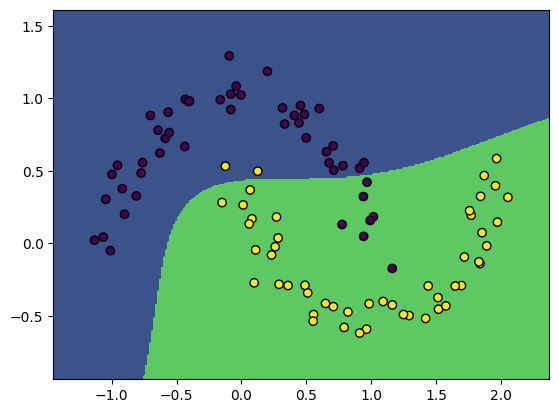

In [54]:
plot_boundary(model, X, y)

PyTorch also gives us an easier (but less flexible) way to define a composition of modules like this. In PyTorch we can define this simple network using `nn.Sequential`

In [55]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1),
    nn.Sigmoid(),
)
model(X).reshape((-1,))

tensor([0.4137, 0.4426, 0.4130, 0.4114, 0.4266, 0.4365, 0.4387, 0.4133, 0.4170,
        0.4331, 0.4234, 0.4035, 0.4403, 0.4344, 0.4228, 0.4257, 0.4007, 0.4126,
        0.4366, 0.4258, 0.4242, 0.4158, 0.4204, 0.4103, 0.4105, 0.4083, 0.4129,
        0.4271, 0.4246, 0.4171, 0.4234, 0.4180, 0.4091, 0.4044, 0.4131, 0.3984,
        0.4099, 0.4231, 0.4272, 0.4215, 0.4147, 0.4217, 0.4255, 0.4148, 0.3993,
        0.4390, 0.4309, 0.4016, 0.4242, 0.4191, 0.4218, 0.4160, 0.3949, 0.4416,
        0.4265, 0.4135, 0.4149, 0.4132, 0.4190, 0.4280, 0.4120, 0.4083, 0.4410,
        0.4006, 0.4081, 0.4271, 0.4249, 0.4122, 0.4067, 0.4246, 0.4367, 0.4143,
        0.4277, 0.4117, 0.4103, 0.4191, 0.4226, 0.4017, 0.4117, 0.4242, 0.4209,
        0.4234, 0.4165, 0.4363, 0.4247, 0.4344, 0.4120, 0.4301, 0.4245, 0.4255,
        0.4127, 0.3957, 0.4097, 0.4162, 0.4233, 0.4223, 0.4079, 0.4274, 0.4114,
        0.3959], grad_fn=<ViewBackward0>)

Here `nn.Sigmoid` is a built-in module that just applies the sigmoid function. Its implementation would look like:

In [56]:
class SigmoidLayer(nn.Module):
    def forward(self, X):
        return torch.sigmoid(X)

We could use this to create a network with several hidden layers:

In [57]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.Sigmoid(),
    nn.Linear(10, 10),
    nn.Sigmoid(),
    nn.Linear(10, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1),
    nn.Sigmoid(),
)
model(X)

tensor([[0.5250],
        [0.5249],
        [0.5249],
        [0.5249],
        [0.5248],
        [0.5249],
        [0.5249],
        [0.5249],
        [0.5251],
        [0.5248],
        [0.5250],
        [0.5250],
        [0.5249],
        [0.5248],
        [0.5248],
        [0.5250],
        [0.5250],
        [0.5249],
        [0.5249],
        [0.5249],
        [0.5249],
        [0.5250],
        [0.5251],
        [0.5251],
        [0.5249],
        [0.5251],
        [0.5251],
        [0.5248],
        [0.5250],
        [0.5248],
        [0.5251],
        [0.5251],
        [0.5251],
        [0.5251],
        [0.5251],
        [0.5250],
        [0.5250],
        [0.5249],
        [0.5249],
        [0.5249],
        [0.5248],
        [0.5248],
        [0.5249],
        [0.5249],
        [0.5250],
        [0.5248],
        [0.5248],
        [0.5250],
        [0.5250],
        [0.5251],
        [0.5250],
        [0.5248],
        [0.5250],
        [0.5249],
        [0.5250],
        [0

PyTorch also provides built-in loss functions. The PyTorch function for the negative log-likelihood for logistic regression is called `nn.functional.binary_cross_entropy`. It has some sharp edges though. 

For one, it expects `y` to be a float type. We can convert a PyTorch `int` tensor into a `float` one by calling the `float` method.

We also see that our sequential model returns a column vector, so `y` should match that as well.

In [58]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

yfloat = y.float().reshape((-1, 1))

for i in range(100):
    predictions = model(X)        # Now we can just call model!
    loss = nn.functional.binary_cross_entropy(predictions, yfloat)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(loss.item())

0.6945388913154602
0.6943228244781494
0.694144606590271
0.6939976215362549
0.6938764452934265
0.6937764883041382
0.6936938762664795
0.693625807762146
0.6935694813728333
0.693523108959198
0.6934845447540283
0.693452775478363
0.6934263706207275
0.6934045553207397
0.6933863162994385
0.6933712959289551
0.6933586597442627
0.6933481693267822
0.6933394074440002
0.6933319568634033
0.6933256387710571
0.6933203935623169
0.693315863609314
0.6933120489120483
0.6933087110519409
0.6933057904243469
0.6933032274246216
0.6933010816574097
0.6932991147041321
0.6932973265647888
0.6932957172393799
0.6932942271232605
0.6932928562164307
0.6932916045188904
0.6932904720306396
0.6932892799377441
0.6932882070541382
0.693287193775177
0.693286120891571
0.6932852268218994
0.693284273147583
0.6932833790779114
0.6932824850082397
0.6932815313339233
0.6932806968688965
0.6932798624038696
0.693278968334198
0.6932781934738159
0.6932772994041443
0.6932764649391174
0.6932756304740906
0.693274736404419
0.6932739019393921
0.6

For convinience, let's definie a wrapper class for our model.

In [59]:
class LogisticRegressionNeuralNetwork(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network = network                   

    def forward(self, X):
        return self.network(X).reshape((-1,))

    def predict_probability(self, X):
        return self.forward(X)

    def predict(self, X):
        return self.forward(X) > 0.5

## Evaluating models

We see that we have a *lot* of options when designing a neural network. So far the choices we've seen are:
- The number of layers
- The number of neurons in each layer
- The activation function
- The learning rate for gradient descent

And this is just the beginning! As we go on, we'll learn about many more options that we have.

Let's take a look at how to make some of these choices. In many real cases, our data will not be a cleanly separated into 2 classes as we've seen. For instance, we can look at a noisier version of the dataset we saw before.

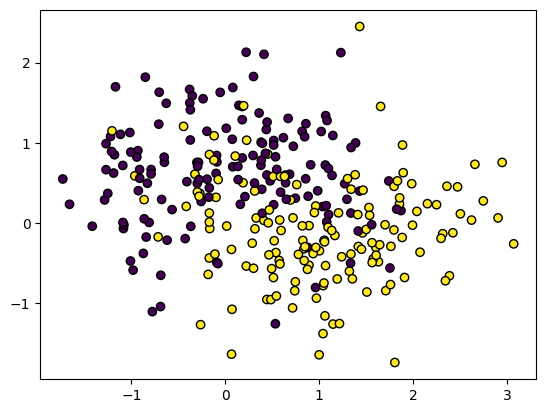

In [60]:
X, y = make_moons(300, noise=0.5)
X, y = torch.tensor(X).float(), torch.tensor(y)
plt.scatter(*X.T, c=y, edgecolor="black")

In reality, this dataset was drawn from the distribution shown below! The optimal classifier would still have an "s-shaped" decision boundary

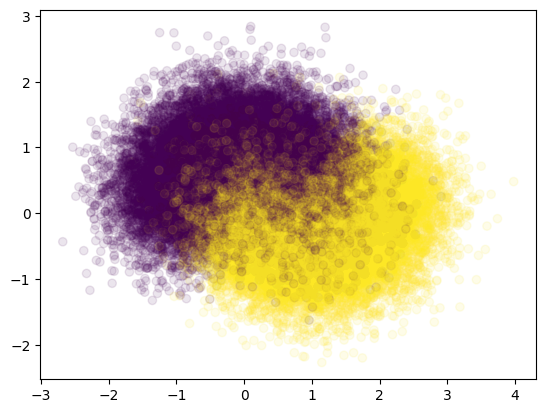

In [61]:
X, y = make_moons(50000, noise=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.1)
pass

Let's split this into training and test sets as we've seen.

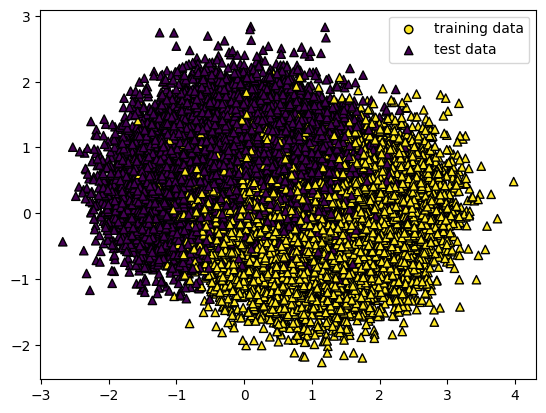

In [ ]:
inds = np.arange(X.shape[0])
np.random.shuffle(inds)
Xtrain, ytrain = torch.tensor(X[inds[:150]]), torch.tensor(y[inds[:150]])
Xtest, ytest = torch.tensor(X[inds[150:]]), torch.tensor(y[inds[150:]])

# We can plot training and test data on the same plot
plt.scatter(*Xtrain.T, c=ytrain, edgecolor="black", marker='o', label='training data')
plt.scatter(*Xtest.T, c=ytest, edgecolor="black", marker='^', label='test data')
plt.legend()


## Underfittting

We'll start by fitting a logistic regression model as we've seen. This time we'll keep track of the loss on both the training data and the test data.

In [63]:
network = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.1)

train_losses, test_losses = [], []
pbar = tqdm.trange(2500)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

  0%|          | 0/2500 [00:00<?, ?it/s]


TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

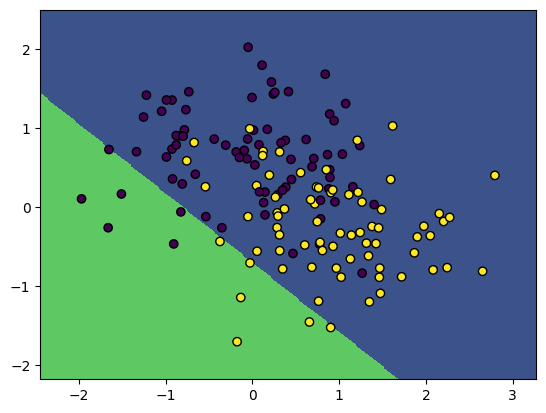

In [64]:
plot_boundary(model, Xtrain, ytrain)

Let's compute the accuracy on both the training and the test data

In [65]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
test_acc = (model.predict(Xtest) == ytest).float().mean()
print('Training accuracy: %.3f, Test accuracy: %.3f' % (train_acc, test_acc))

TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

We can also look at how the loss on both the training and test data changes as we run gradient descent.

Text(0.5, 1.0, 'Loss vs. training iteration')

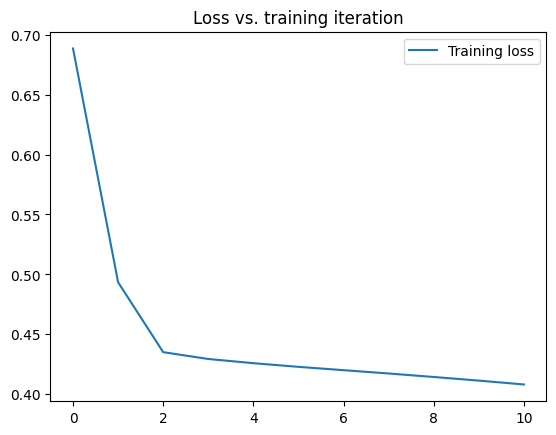

In [288]:
plt.plot(train_losses[:15000:100], label='Training loss')
#plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

Here wee see that both the training loss/accuracy and the test loss/accuracy are quite poor! From our descision boundary plot we can see quite clearly that this is a consequence of our choice of a linear model for this classification problem. We call this problem **underfitting**, meaning that our model is not expressive enough to capture all the intricacies of our data. As we've already seen we can address this by adding neural network layers to increase the expressivity of our model.

## Overfitting

Let's try creating a much more complex model; one with several large neural network layers and fitting it to our data.

In [238]:
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())


Loss: 0.073: 100%|██████████| 25000/25000 [00:41<00:00, 602.24it/s]


We can view the descision boundary and accuracy for this classifier.

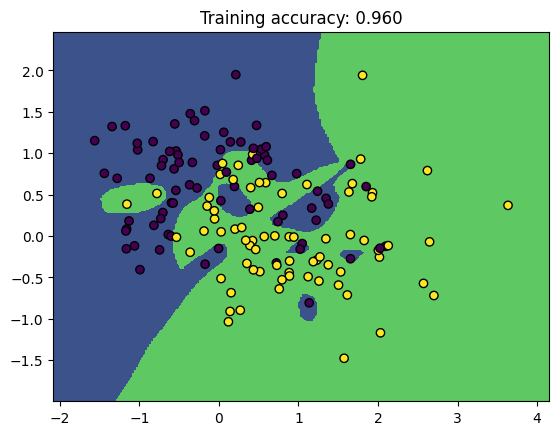

In [247]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)


We see that our model is much more expressive and basically correctly classifies every observation in our training dataset. This is great! However the boundary is quite complex. Let's see what happens when we evaluate on our test set.

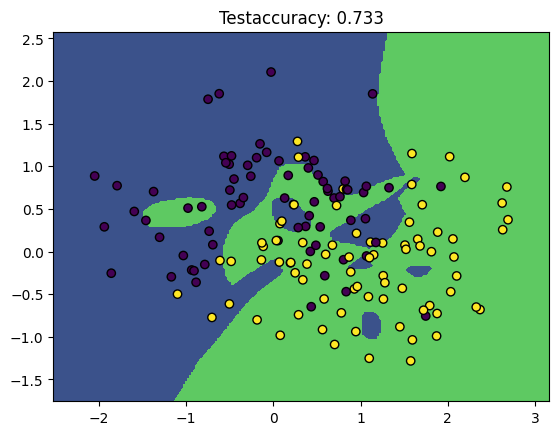

In [250]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)


The accuracy is *much* worse. Rather than capturing the true distribution of classes, our model has captured the training set we happened to draw. This means if we draw a new dataset from the same distribution (like our test set), performance is poor. We call this issue **overfitting**.

Let's see how the training and test loss change over gradient descent.

Text(0.5, 1.0, 'Loss vs. training iteration')

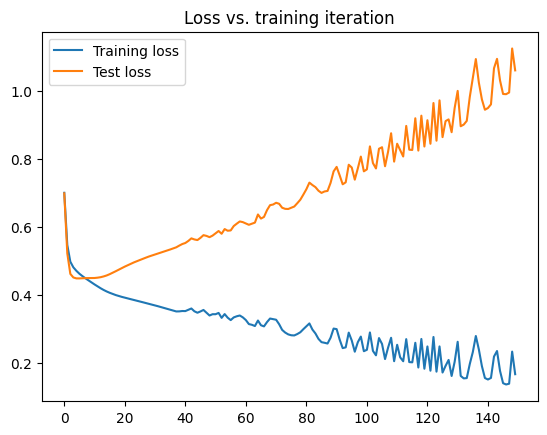

In [242]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

Much of the rest of this class will focus on how to meet the deicate balance of overfitting vs. underfitting!

It's worth noting the the best solution to overfitting is to get more data. If we train with enough data we can avoid overfitting entirely.

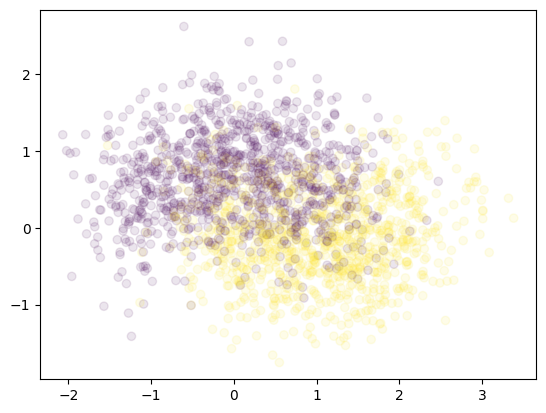

In [270]:
X, y = make_moons(2000, noise=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.1)

In [275]:
X, y = torch.tensor(X).float(), torch.tensor(y)
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.1)

train_losses, test_losses = [], []
pbar = tqdm.trange(2500)
for i in pbar:
    predictions = model(X)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, y.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

/var/folders/t9/fjsr8h1x7c7cg4vqw_xhjq2w0000gn/T/ipykernel_79454/2923296796.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X, y = torch.tensor(X).float(), torch.tensor(y)
Loss: 0.390: 100%|██████████| 2500/2500 [00:16<00:00, 151.68it/s]


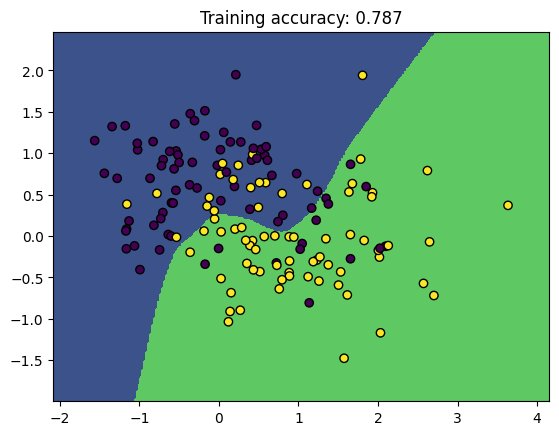

In [276]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

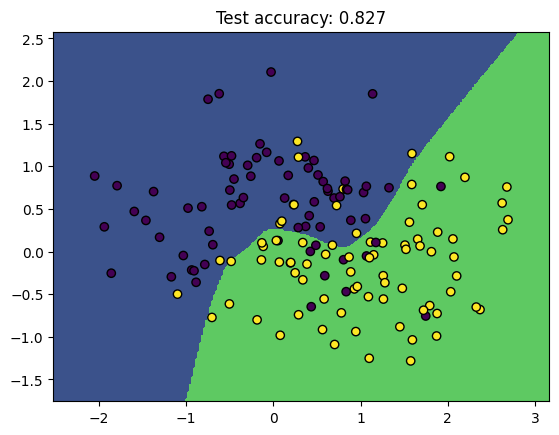

In [277]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

Text(0.5, 1.0, 'Loss vs. training iteration')

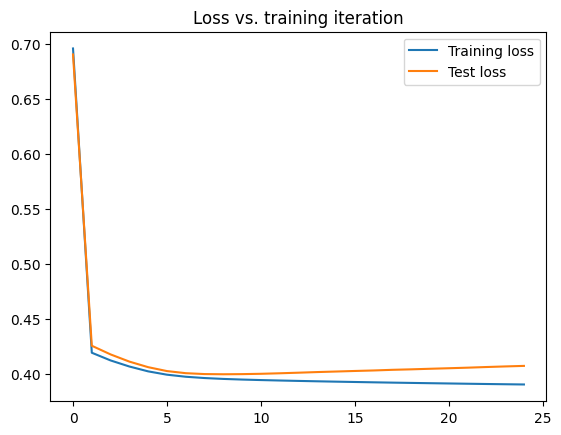

In [278]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

Unfortunately, this often isn't realistic. Data is hard to collect and more data means our model is slower and more expensive to train.

## Early stopping

Let's return to the original case

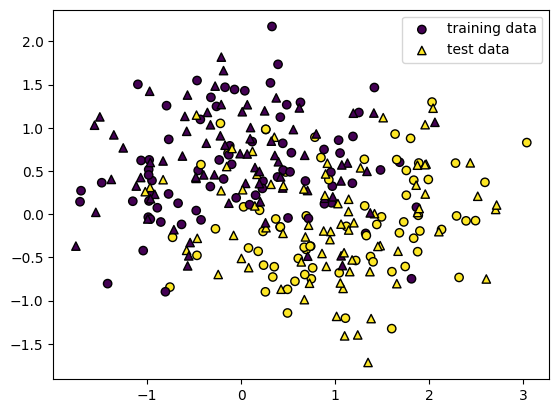

In [280]:
X, y = make_moons(300, noise=0.5)
X, y = torch.tensor(X).float(), torch.tensor(y)

inds = np.arange(X.shape[0])
np.random.shuffle(inds)
Xtrain, ytrain = X[inds[:150]], y[inds[:150]]
Xtest, ytest = X[inds[150:]], y[inds[150:]]

# We can plot training and test data on the same plot
plt.scatter(*Xtrain.T, c=ytrain, edgecolor="black", marker='o', label='training data')
plt.scatter(*Xtest.T, c=ytest, edgecolor="black", marker='^', label='test data')
plt.legend()

Let's try a network somewhere in-between, with just a single hidden layer.

In [251]:
network = nn.Sequential(
    nn.Linear(2, 100),
    nn.ReLU(),
    nn.Linear(100, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

Loss: 0.366: 100%|██████████| 25000/25000 [00:28<00:00, 870.32it/s] 


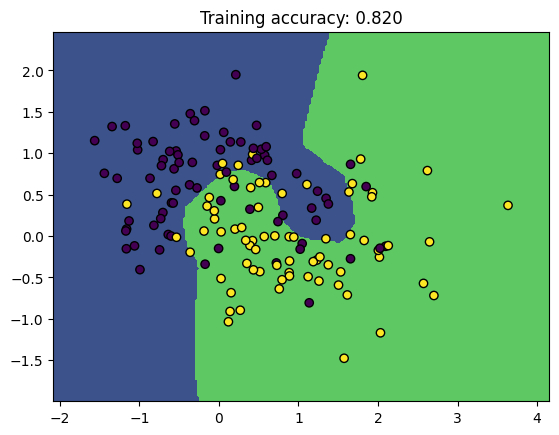

In [252]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)


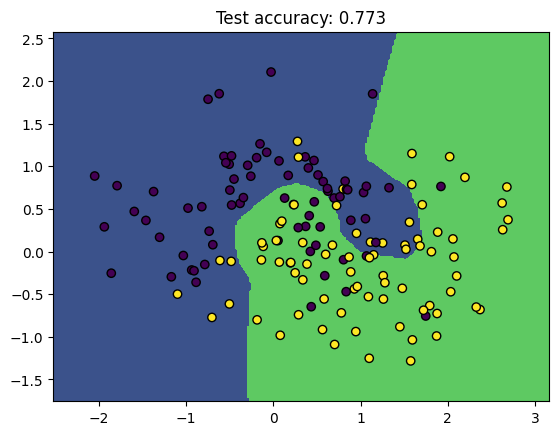

In [253]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

We see that this network is more consistent between train and test, and now performs better on test data! Let's take a look at the plot of training and test loss.

Text(0.5, 1.0, 'Loss vs. training iteration')

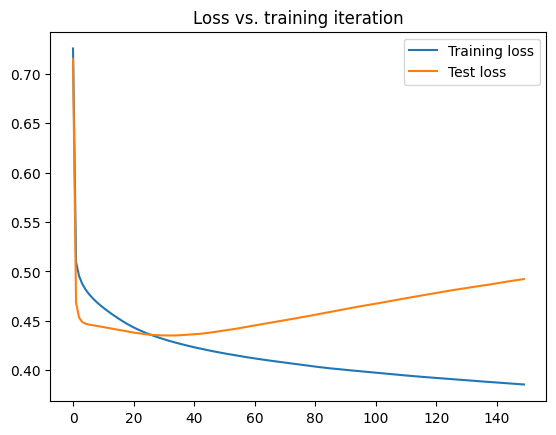

In [254]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

We still see that both drop quickly, but that test loss increases after a point. How might we use this to pick a better model?

One option would be to just use the model where the test loss is lowest. After all, that is our ultimate goal. There are different ways we can think about implementing this. One way to to have gradient descent stop when the test loss begins to increase. We call this approach **early stopping** 

In [256]:
network = nn.Sequential(
    nn.Linear(2, 100),
    nn.ReLU(),
    nn.Linear(100, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

    if i > 50 and test_loss.item() > test_losses[-2]:
        break

Loss: 0.481:   1%|▏         | 346/25000 [00:00<00:30, 810.31it/s]


Text(0.5, 1.0, 'Loss vs. training iteration')

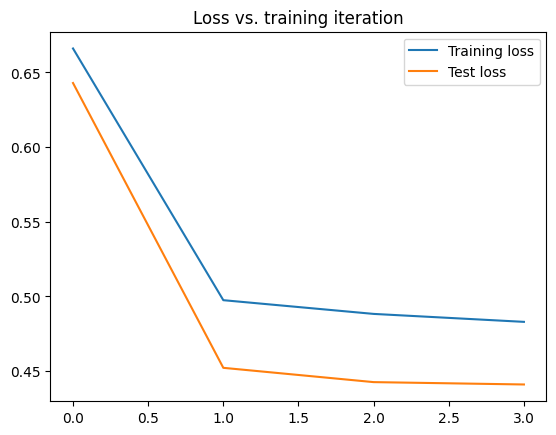

In [257]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

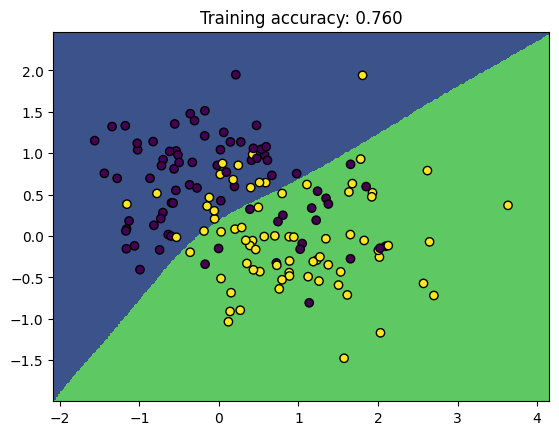

In [258]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

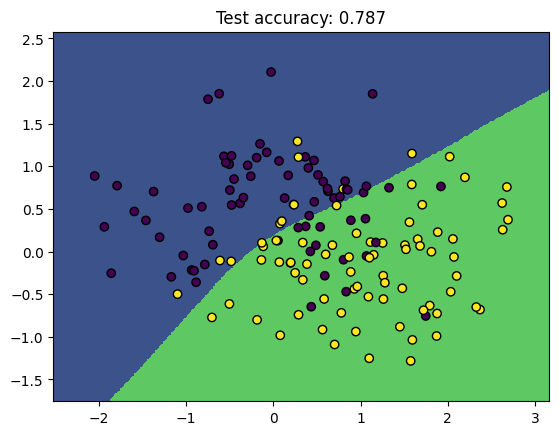

In [259]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

Here we see that actually we do the best so far with this approach!

We could also try our early-stopping approach with our more complex network.

In [260]:
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, test_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    test_loss = torch.nn.functional.binary_cross_entropy(model(Xtest), ytest.flatten().float())
    test_losses.append(test_loss.item())

    if i > 50 and test_loss.item() > test_losses[-2]:
        break

Loss: 0.465:   2%|▏         | 382/25000 [00:00<00:42, 574.88it/s]


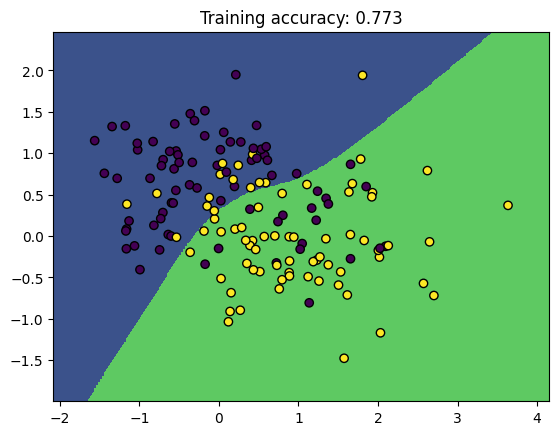

In [261]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

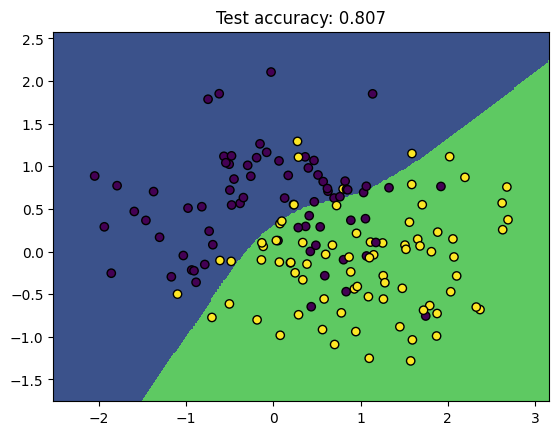

In [262]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)

Text(0.5, 1.0, 'Loss vs. training iteration')

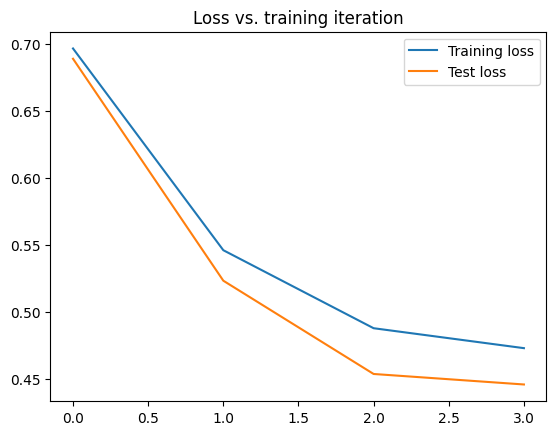

In [263]:
plt.plot(train_losses[:15000:100], label='Training loss')
plt.plot(test_losses[:15000:100], label='Test loss')
plt.legend()
plt.title('Loss vs. training iteration')

## Train, validation and test

There is an issue here though! We've now used out test set to (indirectly) train our model. Both by using it to choose the number of layers and by using it to determine how long to run our optimization! This means that our model choice will be biased by our choice of test set, so how can we trust that our test loss or accuracy will actually be a good measure of the real-world performance of our model?

To deal with this issue we will typically split our data into 3 parts that we'll call **training**, **validation** and **test**. We'll use the validation portion as the portion to fit the model and the test set as the portion we use to estimate how well it will do in practice.

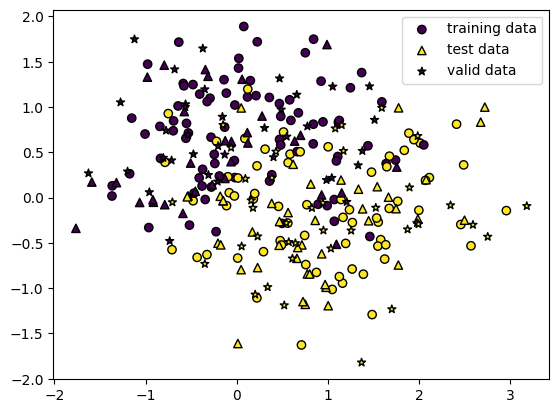

In [282]:
X, y = make_moons(300, noise=0.5)
X, y = torch.tensor(X).float(), torch.tensor(y)

inds = np.arange(X.shape[0])
np.random.shuffle(inds)
Xtrain, ytrain = X[inds[:150]], y[inds[:150]]
Xvalid, yvalid = X[inds[150:225]], y[inds[150:225]]
Xtest, ytest = X[inds[225:]], y[inds[225:]]

# We can plot training and test data on the same plot
plt.scatter(*Xtrain.T, c=ytrain, edgecolor="black", marker='o', label='training data')
plt.scatter(*Xtest.T, c=ytest, edgecolor="black", marker='^', label='test data')
plt.scatter(*Xvalid.T, c=yvalid, edgecolor="black", marker='*', label='valid data')
plt.legend()

In [283]:
network = nn.Sequential(
    nn.Linear(2, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1),
    nn.Sigmoid(),
)
model = LogisticRegressionNeuralNetwork(network)   

optimizer = optim.SGD(model.parameters(), lr=0.03)

train_losses, valid_losses = [], []
pbar = tqdm.trange(25000)
for i in pbar:
    predictions = model(Xtrain)        # Now we can just call model!
    loss = torch.nn.functional.binary_cross_entropy(predictions, ytrain.flatten().float())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_description('Loss: %.3f' % loss.item())

    train_losses.append(loss.item())
    valid_loss = torch.nn.functional.binary_cross_entropy(model(Xvalid), yvalid.flatten().float())
    valid_losses.append(valid_loss.item())

    if i > 50 and valid_loss.item() > valid_losses[-2]:
        break

Loss: 0.406:   4%|▍         | 1060/25000 [00:02<00:46, 513.32it/s]


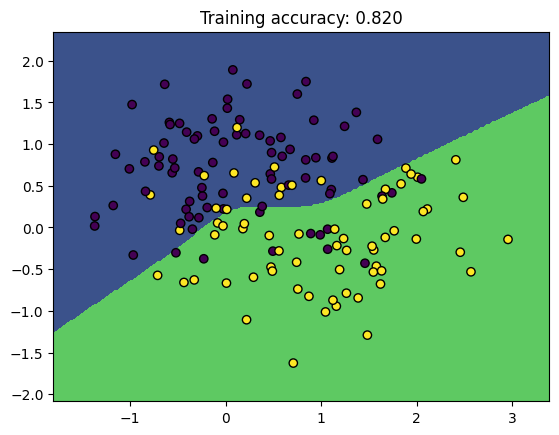

In [284]:
train_acc = (model.predict(Xtrain) == ytrain).float().mean()
plot_boundary(model, Xtrain, ytrain, title='Training accuracy: %.3f' % train_acc)

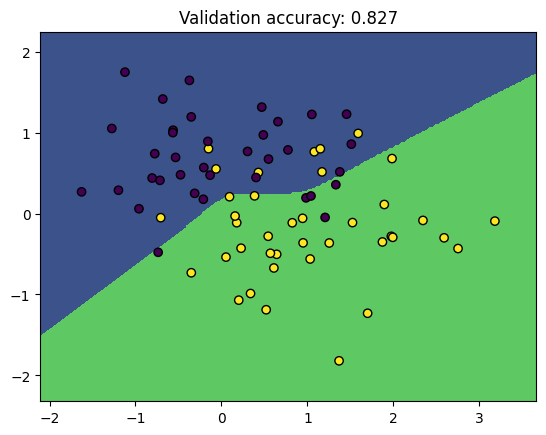

In [287]:
test_acc = (model.predict(Xvalid) == yvalid).float().mean()
plot_boundary(model, Xvalid, yvalid, title='Validation accuracy: %.3f' % test_acc)

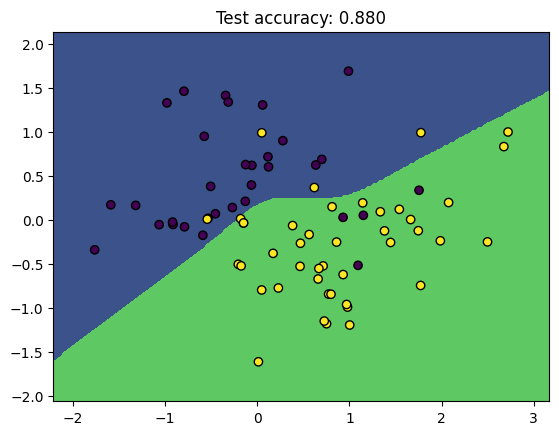

In [285]:
test_acc = (model.predict(Xtest) == ytest).float().mean()
plot_boundary(model, Xtest, ytest, title='Test accuracy: %.3f' % test_acc)